# **MODEL TRAINING NOTEBOOK**
-----

### *Stage 3 of the total pipeline are performed in this notebook:*

#### **Stage 1**: Sensor Characterization (No Needle Data)

- **Static Baseline**  → quantify sensor noise floor
- **Dynamic No Needle** → model breathing-induced deformation

#### **Stage 2**: Signal Compensation

- Remove noise bias
- Remove datapoints where the mm magnitude of error is outside the ROI
- Produce "cleaned FBG signal"

#### **Stage 3**: Supervised Learning

- **Input**: cleaned FBG features
- **Target**: CV-measured MM_Magnitude
- **Train regression model**

#### **Stage 4**: Validation
- Predict on unseen trials, removing breathing effects using breathing model
- Compare predicted vs true error

-----

In [145]:
'''
IMPORTS
'''

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.base import clone
from sklearn.model_selection import GroupKFold, cross_val_predict, cross_val_score, learning_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score, explained_variance_score

In [146]:
'''
CONFIG
'''
sns.set(style="whitegrid")
RANDOM_STATE = 42

In [147]:
'''
MODELS
'''

primary_model = Pipeline([
                            ("scaler", StandardScaler()),
                            ("ridge", Ridge(alpha=1.0))
                        ])

baseline_model = DummyRegressor(strategy="mean")

## 1. Load event-level datasets

The static dataset is used for model development and validation.  
The dynamic dataset is used to test generalization under respiratory motion.

In [148]:
'''
LOAD NEW EVENT-LEVEL DATA
'''

df_static = pd.read_csv("static_ideal_event_train.csv")
static_df_full = pd.read_csv("static_df.csv")   # full time-series for static event snippets

df_dynamic = pd.read_csv("dynamic_ideal_event_train.csv")
dynamic_df_full = pd.read_csv("dynamic_df.csv")  # optional if available for dynamic snippets

## 2. Define features and models

The baseline model uses only the main event-energy feature.  
The lung-aware model adds breathing-phase and breathing-estimate features to test whether respiratory motion can be partially compensated.

In [149]:
'''
FEATURES
'''

leaky_cols = [
                    "mm_min_value", "mm_median", "mm_mean",
                    "mm_min_time_sec", "mm_to_trough_dt_sec", "center_to_trough_dt_sec"
             ]

basic_features = ["power_energy"]

lung_features =    [
                        "power_energy", 
                        "Breath_Percent_sin",
                        "Breath_Percent_cos",
                        "Breath_PWM_scaled", 
                        "power_breath_at_event",
                        "power_minus_breath"
                    ]

In [150]:
'''
TARGET
'''

TARGET_RAW = "mm_min_value"
TARGET = "target_abs_error"

df_static[TARGET] = np.abs(df_static[TARGET_RAW])
df_dynamic[TARGET] = np.abs(df_dynamic[TARGET_RAW])

print("Static shape:", df_static.shape)
print("Dynamic shape:", df_dynamic.shape)

Static shape: (64, 33)
Dynamic shape: (39, 32)


In [151]:
'''
STATIC SETS
'''
X_static_basic = df_static[basic_features].copy()
X_static_lung = df_static[lung_features].copy()

y_static = df_static[TARGET].copy()

groups_static = df_static["Trial_File"].copy()

In [152]:
'''
DYNAMIC SETS 
'''
X_dynamic_basic = df_dynamic[basic_features].copy()
X_dynamic_lung = df_dynamic[lung_features].copy()

y_dynamic = df_dynamic[TARGET].copy()

groups_dynamic = df_dynamic["Trial_File"].copy()

In [153]:
'''
MODELS
'''
primary_model = Pipeline([
                                ("scaler", StandardScaler()),
                                ("ridge", Ridge(alpha=1.0))
                         ])

baseline_model = DummyRegressor(strategy="mean")

## 3. Dataset overview

Before modeling, the event distribution across nominal classes is checked to confirm class balance and total sample size.

STATIC DATASET SUMMARY
----------------------
Total events: 64
Total trial files: 25

Events per class:
Nominal_Class
0mm    22
1mm    21
2mm    21
Name: count, dtype: int64

Trial files per class:
Nominal_Class
0mm    9
1mm    8
2mm    8
Name: Trial_File, dtype: int64


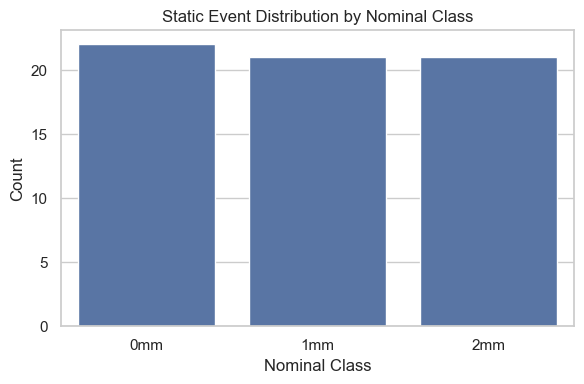

In [154]:
print("STATIC DATASET SUMMARY")
print("----------------------")
print(f"Total events: {len(df_static)}")
print(f"Total trial files: {df_static['Trial_File'].nunique()}")
print("\nEvents per class:")
print(df_static["Nominal_Class"].value_counts())
print("\nTrial files per class:")
print(df_static.groupby("Nominal_Class")["Trial_File"].nunique())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_static, x="Nominal_Class")
plt.title("Static Event Distribution by Nominal Class")
plt.xlabel("Nominal Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 4. Stage 1 — Static feature-target relationship

This section checks whether the static FBG feature space contains useful information about true absolute error.

A visible trend here supports the idea that static event-level prediction is a learnable problem.

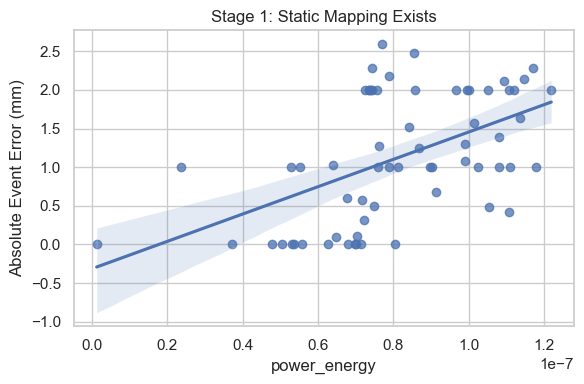

Pearson r(power_energy, absolute error) = 0.513


In [155]:
plt.figure(figsize=(6, 4))
sns.regplot(
    x=df_static["power_energy"],
    y=df_static[TARGET],
    scatter_kws={"alpha": 0.75}
)
plt.xlabel("power_energy")
plt.ylabel("Absolute Event Error (mm)")
plt.title("Stage 1: Static Mapping Exists")
plt.tight_layout()
plt.show()

corr = np.corrcoef(df_static["power_energy"], df_static[TARGET])[0, 1]
print(f"Pearson r(power_energy, absolute error) = {corr:.3f}")

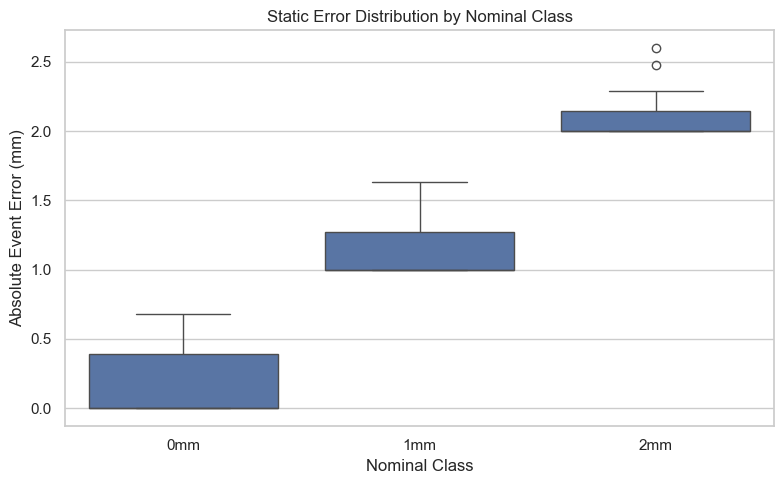

In [156]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_static, x="Nominal_Class", y=TARGET)
plt.title("Static Error Distribution by Nominal Class")
plt.xlabel("Nominal Class")
plt.ylabel("Absolute Event Error (mm)")
plt.tight_layout()
plt.show()

## 5. Stage 1 — Static model validation

A simple interpretable model is first evaluated under static conditions using only the baseline feature set.

This establishes whether the static problem is learnable before introducing respiratory motion.

In [157]:
'''
GROUPED TRAIN / TEST SPLIT
'''

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X_static_basic, y_static, groups=groups_static))

X_train_basic = X_static_basic.iloc[train_idx]
X_test_basic = X_static_basic.iloc[test_idx]
y_train_static = y_static.iloc[train_idx]
y_test_static = y_static.iloc[test_idx]
groups_train_static = groups_static.iloc[train_idx]
groups_test_static = groups_static.iloc[test_idx]

gkf_static = GroupKFold(n_splits=min(5, groups_static.nunique()))
gkf_train_static = GroupKFold(n_splits=min(5, groups_train_static.nunique()))

print("Train groups:", groups_train_static.nunique())
print("Test groups:", groups_test_static.nunique())

Train groups: 18
Test groups: 7


In [158]:
'''
PRIMARY STATIC MODEL 
'''

static_basic_model = clone(primary_model)
static_basic_model.fit(X_train_basic, y_train_static)
y_test_pred_static = static_basic_model.predict(X_test_basic)


# Fit dummy baseline comparison
dummy_fit = clone(baseline_model)
dummy_fit.fit(X_train_basic, y_train_static)
y_test_pred_dummy = dummy_fit.predict(X_test_basic)

In [159]:
'''
PRIMARY STATIC MODEL EVAL
'''

print("STATIC HELD-OUT PERFORMANCE")
print("---------------------------")
print(f"Baseline MAE: {mean_absolute_error(y_test_static, y_test_pred_dummy):.3f}")
print(f"Model MAE:    {mean_absolute_error(y_test_static, y_test_pred_static):.3f}")
print()
print(f"Baseline R2:  {r2_score(y_test_static, y_test_pred_dummy):.3f}")
print(f"Model R2:     {r2_score(y_test_static, y_test_pred_static):.3f}")

ridge_coef = static_basic_model.named_steps["ridge"].coef_[0]
ridge_intercept = static_basic_model.named_steps["ridge"].intercept_

print()
print(f"Ridge coefficient (power_energy): {ridge_coef:.6f}")
print(f"Ridge intercept: {ridge_intercept:.6f}")

STATIC HELD-OUT PERFORMANCE
---------------------------
Baseline MAE: 0.494
Model MAE:    0.523

Baseline R2:  -0.083
Model R2:     0.056

Ridge coefficient (power_energy): 0.462469
Ridge intercept: 1.179034


In [160]:
'''
PRIMARY STATIC MODEL GROUPED CV
'''

cv_r2_static = cross_val_score(
                                clone(primary_model),
                                X_static_basic,
                                y_static,
                                cv=gkf_static,
                                groups=groups_static,
                                scoring="r2",
                                n_jobs=-1
                            )

cv_rmse_static = -cross_val_score(
                                    clone(primary_model),
                                    X_static_basic,
                                    y_static,
                                    cv=gkf_static,
                                    groups=groups_static,
                                    scoring="neg_root_mean_squared_error",
                                    n_jobs=-1
                                )

cv_mae_static = -cross_val_score(
                                    clone(primary_model),
                                    X_static_basic,
                                    y_static,
                                    cv=gkf_static,
                                    groups=groups_static,
                                    scoring="neg_mean_absolute_error",
                                    n_jobs=-1
                                )

print("STATIC GROUPED CV SUMMARY")
print("-------------------------")
print(f"R2 mean ± std:   {cv_r2_static.mean():.3f} ± {cv_r2_static.std():.3f}")
print(f"RMSE mean ± std: {cv_rmse_static.mean():.3f} ± {cv_rmse_static.std():.3f}")
print(f"MAE mean ± std:  {cv_mae_static.mean():.3f} ± {cv_mae_static.std():.3f}")

STATIC GROUPED CV SUMMARY
-------------------------
R2 mean ± std:   0.244 ± 0.279
RMSE mean ± std: 0.680 ± 0.254
MAE mean ± std:  0.627 ± 0.261


In [161]:
'''
PRIMARY STATIC MODEL GROUPED CV PREDICTIONS
'''

cv_pred_static = cross_val_predict(
                                        clone(primary_model),
                                        X_static_basic,
                                        y_static,
                                        groups=groups_static,
                                        cv=gkf_static,
                                        n_jobs=-1
                                  )

cv_pred_static_df = pd.DataFrame({
                                        "Trial_File": groups_static.values,
                                        "Nominal_Class": df_static["Nominal_Class"].values,
                                        "y_true": y_static.values,
                                        "y_pred": cv_pred_static
                                  })

cv_pred_static_df["abs_error"] = np.abs(cv_pred_static_df["y_true"] - cv_pred_static_df["y_pred"])

print("STATIC CV OVERALL")
print("-----------------")
print("R2:", r2_score(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"]))
print("RMSE:", np.sqrt(mean_squared_error(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"])))
print("MAE:", mean_absolute_error(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"]))

STATIC CV OVERALL
-----------------
R2: 0.21877390807725228
RMSE: 0.7223432743145359
MAE: 0.6232516735848368


### Static diagnostic plots

These plots assess whether the static model is both numerically reasonable and behaviorally interpretable.

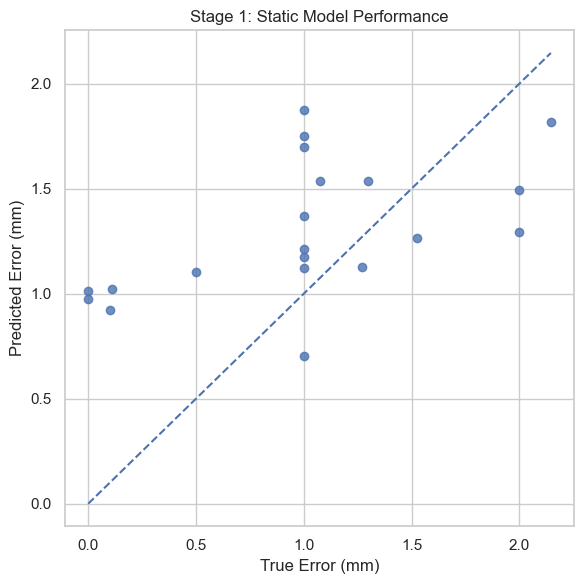

In [162]:
# Held-out actual vs predicted

plt.figure(figsize=(6, 6))
plt.scatter(y_test_static, y_test_pred_static, alpha=0.8)

lims = [
            min(y_test_static.min(), y_test_pred_static.min()),
            max(y_test_static.max(), y_test_pred_static.max())
        ]

plt.plot(lims, lims, "--")
plt.xlabel("True Error (mm)")
plt.ylabel("Predicted Error (mm)")
plt.title("Stage 1: Static Model Performance")
plt.grid(True)
plt.tight_layout()
plt.show()

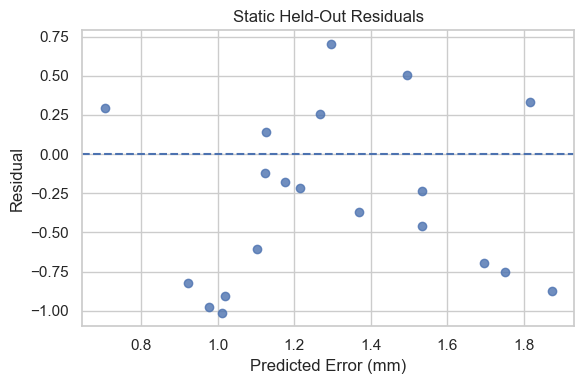

In [163]:
# Residual plot
residuals_static = y_test_static - y_test_pred_static

plt.figure(figsize=(6, 4))
plt.scatter(y_test_pred_static, residuals_static, alpha=0.8)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Error (mm)")
plt.ylabel("Residual")
plt.title("Static Held-Out Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()

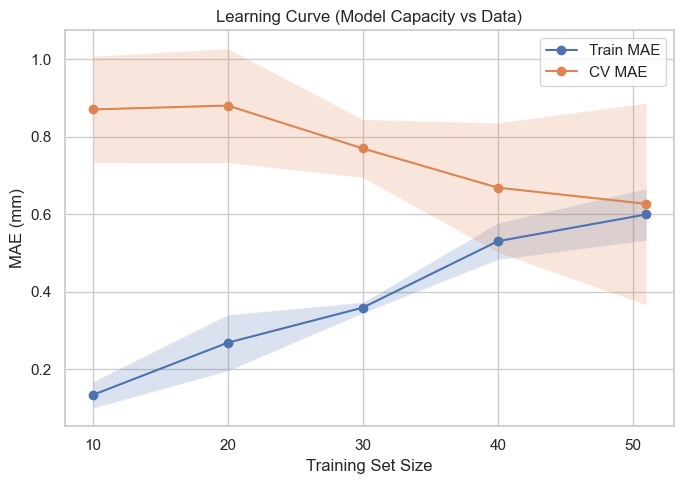

In [164]:
# Learning curve
train_sizes, train_scores, val_scores = learning_curve(
                                                            estimator=clone(primary_model),
                                                            X=X_static_basic,
                                                            y=y_static,
                                                            groups=groups_static,
                                                            cv=gkf_static,
                                                            scoring="neg_mean_absolute_error",
                                                            train_sizes=np.linspace(0.2, 1.0, 5),
                                                            n_jobs=-1
                                                        )

train_mae = -train_scores.mean(axis=1)
train_mae_std = train_scores.std(axis=1)
val_mae = -val_scores.mean(axis=1)
val_mae_std = val_scores.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mae, marker="o", label="Train MAE")
plt.fill_between(train_sizes, train_mae - train_mae_std, train_mae + train_mae_std, alpha=0.2)
plt.plot(train_sizes, val_mae, marker="o", label="CV MAE")
plt.fill_between(train_sizes, val_mae - val_mae_std, val_mae + val_mae_std, alpha=0.2)
plt.xlabel("Training Set Size")
plt.ylabel("MAE (mm)")
plt.title("Learning Curve (Model Capacity vs Data)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Static robustness checks

To strengthen defendability, the static model is evaluated using repeated grouped holdout splits and a shuffled-label sanity test.

These checks help distinguish real signal learning from chance structure.

In [165]:
'''
REPEATED GROUPED HOLDOUT STABILITY
PRIMARY STATIC MODEL
'''

# Repeated grouped holdout
n_repeats = 100
repeated_rows = []

splitter = GroupShuffleSplit(n_splits=n_repeats, test_size=0.25, random_state=RANDOM_STATE)

for split_id, (tr_idx, te_idx) in enumerate(splitter.split(X_static_basic, y_static, groups_static)):
    X_tr = X_static_basic.iloc[tr_idx]
    X_te = X_static_basic.iloc[te_idx]
    y_tr = y_static.iloc[tr_idx]
    y_te = y_static.iloc[te_idx]

    model = clone(primary_model)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)

    repeated_rows.append({
                            "split": split_id,
                            "R2": r2_score(y_te, pred),
                            "RMSE": np.sqrt(mean_squared_error(y_te, pred)),
                            "MAE": mean_absolute_error(y_te, pred)
                        })

repeated_results_df = pd.DataFrame(repeated_rows)

print("REPEATED GROUPED HOLDOUT SUMMARY")
print("--------------------------------")
print(repeated_results_df[["R2", "RMSE", "MAE"]].describe())
print()
print(f"Median R2: {repeated_results_df['R2'].median():.3f}")
print(f"Median RMSE: {repeated_results_df['RMSE'].median():.3f}")
print(f"Median MAE: {repeated_results_df['MAE'].median():.3f}")
print(f"% splits with R2 > 0: {(repeated_results_df['R2'] > 0).mean() * 100:.1f}%")

REPEATED GROUPED HOLDOUT SUMMARY
--------------------------------
               R2        RMSE         MAE
count  100.000000  100.000000  100.000000
mean    -0.031373    0.741145    0.646475
std      0.688450    0.119292    0.119095
min     -5.551730    0.425910    0.365785
25%     -0.072979    0.664421    0.567776
50%      0.106968    0.747701    0.644780
75%      0.296300    0.810402    0.718172
max      0.549744    1.079044    0.963159

Median R2: 0.107
Median RMSE: 0.748
Median MAE: 0.645
% splits with R2 > 0: 65.0%


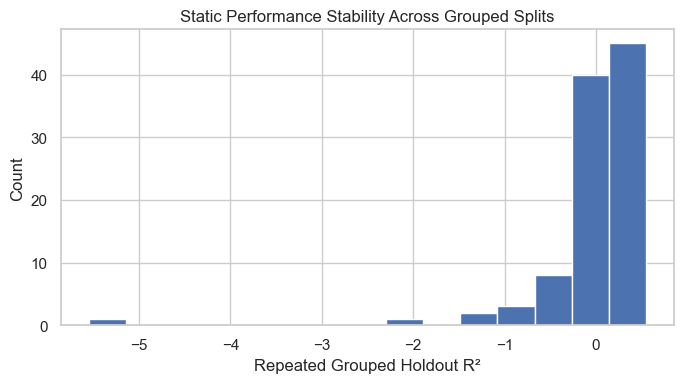

In [166]:
plt.figure(figsize=(7, 4))
plt.hist(repeated_results_df["R2"], bins=15)
plt.xlabel("Repeated Grouped Holdout R²")
plt.ylabel("Count")
plt.title("Static Performance Stability Across Grouped Splits")
plt.grid(True)
plt.tight_layout()
plt.show()

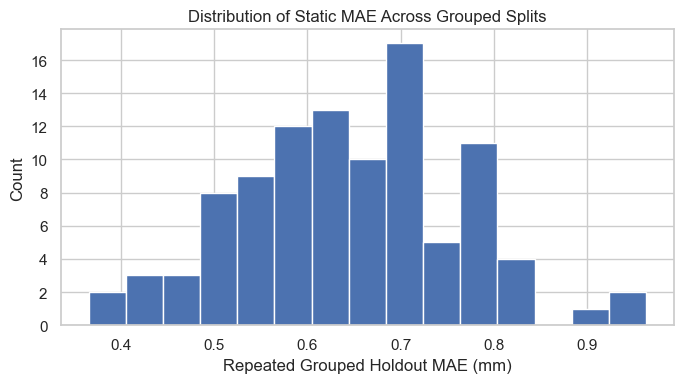

In [167]:
plt.figure(figsize=(7, 4))
plt.hist(repeated_results_df["MAE"], bins=15)
plt.xlabel("Repeated Grouped Holdout MAE (mm)")
plt.ylabel("Count")
plt.title("Distribution of Static MAE Across Grouped Splits")
plt.grid(True)
plt.tight_layout()
plt.show()

In [168]:
# Shuffled-label sanity test
rng = np.random.default_rng(RANDOM_STATE)
y_static_shuffled = pd.Series(rng.permutation(y_static.values), index=y_static.index)

shuffle_r2 = cross_val_score(
                                clone(primary_model),
                                X_static_basic,
                                y_static_shuffled,
                                cv=gkf_static,
                                groups=groups_static,
                                scoring="r2",
                                n_jobs=-1
                            )

shuffle_mae = -cross_val_score(
                                    clone(primary_model),
                                    X_static_basic,
                                    y_static_shuffled,
                                    cv=gkf_static,
                                    groups=groups_static,
                                    scoring="neg_mean_absolute_error",
                                    n_jobs=-1
                              )

print("SHUFFLED-LABEL GROUPED CV SUMMARY")
print("---------------------------------")
print(f"R2 mean ± std: {shuffle_r2.mean():.3f} ± {shuffle_r2.std():.3f}")
print(f"MAE mean ± std: {shuffle_mae.mean():.3f} ± {shuffle_mae.std():.3f}")
print()
print("Real vs shuffled MAE:")
print(f"Real MAE mean:     {cv_mae_static.mean():.3f}")
print(f"Shuffled MAE mean: {shuffle_mae.mean():.3f}")

SHUFFLED-LABEL GROUPED CV SUMMARY
---------------------------------
R2 mean ± std: -0.067 ± 0.175
MAE mean ± std: 0.700 ± 0.210

Real vs shuffled MAE:
Real MAE mean:     0.627
Shuffled MAE mean: 0.700


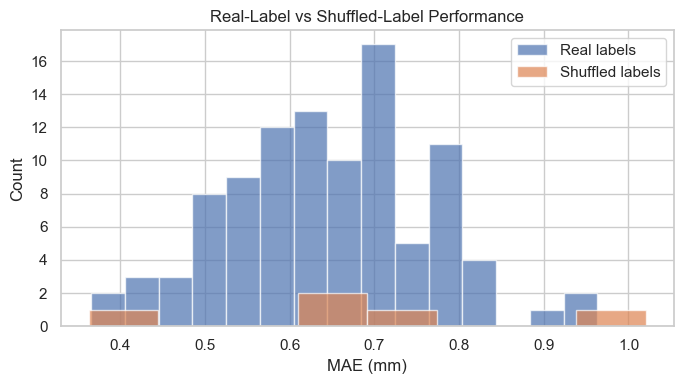

In [169]:
plt.figure(figsize=(7, 4))
plt.hist(repeated_results_df["MAE"], bins=15, alpha=0.7, label="Real labels")
plt.hist(shuffle_mae, bins=8, alpha=0.7, label="Shuffled labels")
plt.xlabel("MAE (mm)")
plt.ylabel("Count")
plt.title("Real-Label vs Shuffled-Label Performance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Static event-level interpretability

These plots qualitatively inspect whether predicted event-level error follows the event structure seen in the full time-series.

This section supports the static model with interpretable event snippets rather than only aggregate metrics.

In [170]:
# Build held-out prediction dataframe
pred_df_static = df_static.loc[X_test_basic.index, [
                                                        "Trial_File",
                                                        "Event_ID",
                                                        "Nominal_Class",
                                                        "event_center_time_sec",
                                                        "event_start_time_sec",
                                                        "event_end_time_sec",
                                                        "mm_min_value"
                                                    ]].copy()

pred_df_static["y_true"] = y_test_static.values
pred_df_static["y_pred"] = np.asarray(y_test_pred_static)
pred_df_static["abs_error"] = np.abs(pred_df_static["y_true"] - pred_df_static["y_pred"])

pred_df_static = pred_df_static.sort_values(
                                                ["Nominal_Class", "Trial_File", "event_center_time_sec"]
                                            ).reset_index(drop=True)

# Keep this readable
pred_df_static = pred_df_static.head(10)

print("Held-out events shown:", len(pred_df_static))
display(pred_df_static.head())

Held-out events shown: 10


,Trial_File,Event_ID,Nominal_Class,event_center_time_sec,event_start_time_sec,event_end_time_sec,mm_min_value,y_true,y_pred,abs_error
0,0mm_1.csv,0mm_1.csv__event_1,0mm,12.606500,12.275593,12.903699,0.497678,0.497678,1.101711,0.604033
1,0mm_1.csv,0mm_1.csv__event_3,0mm,31.447778,31.118929,31.742491,0.000000,0.000000,0.976669,0.976669
2,0mm_9.csv,0mm_9.csv__event_1,0mm,12.732752,12.404308,13.033321,0.112114,0.112114,1.019946,0.907832
3,0mm_9.csv,0mm_9.csv__event_2,0mm,21.412847,21.085701,21.711976,0.000000,0.000000,1.012536,1.012536
4,0mm_9.csv,0mm_9.csv__event_3,0mm,30.853364,30.558091,31.150895,0.101219,0.101219,0.921649,0.820430


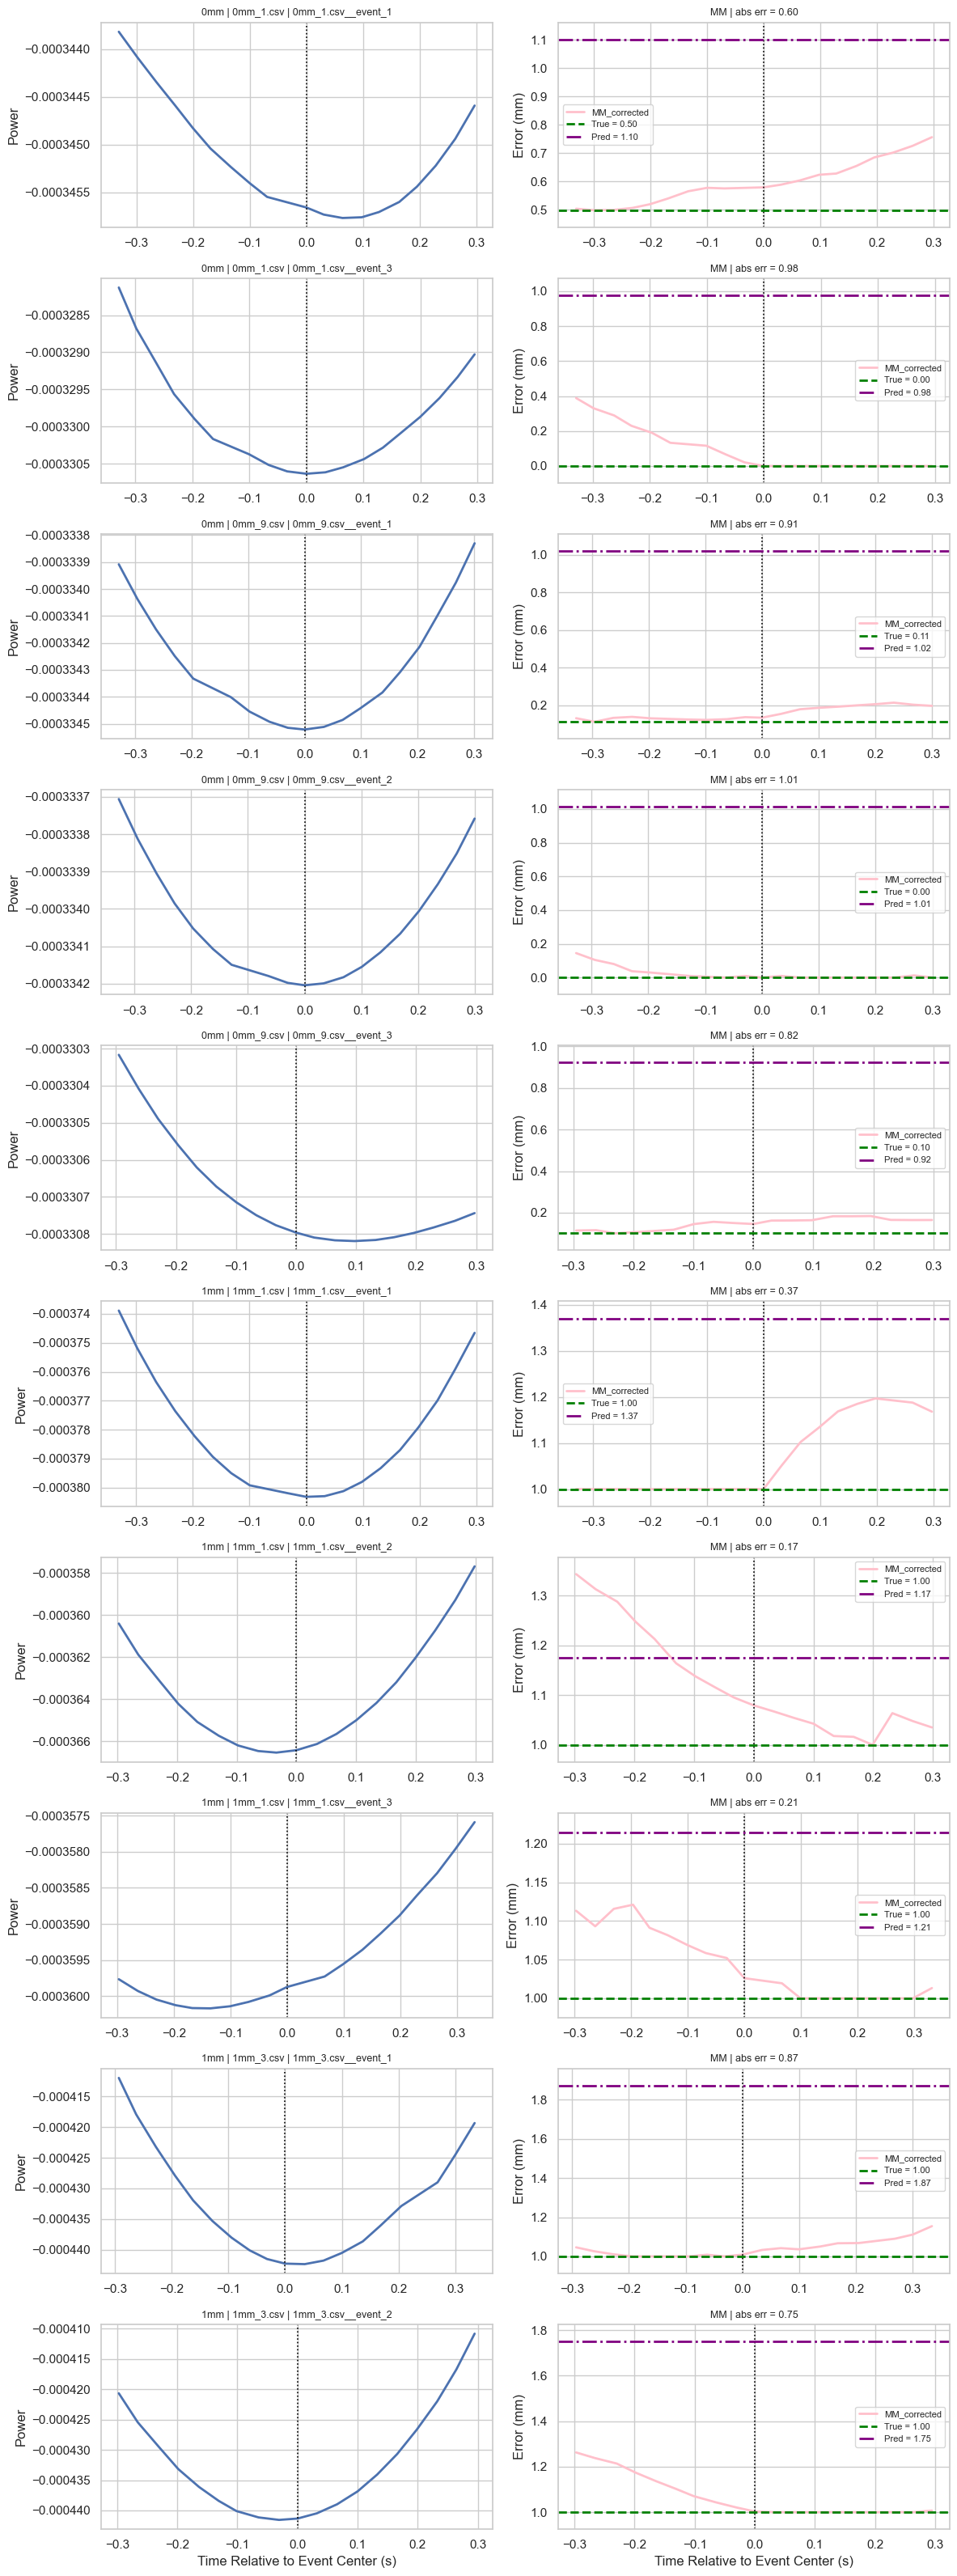

In [171]:
# Event snippets
n = len(pred_df_static)

if n == 0:
    print("No held-out events found.")
else:
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 3.2 * n), sharex=False)

    if n == 1:
        axes = np.array(axes).reshape(1, 2)

    for i, (_, ev) in enumerate(pred_df_static.iterrows()):
        trial_file = ev["Trial_File"]

        win = static_df_full[
                                (static_df_full["Trial_File"] == trial_file) &
                                (static_df_full["time_sec"] >= ev["event_start_time_sec"]) &
                                (static_df_full["time_sec"] <= ev["event_end_time_sec"])
                            ].copy()

        if len(win) == 0:
            axes[i, 0].set_visible(False)
            axes[i, 1].set_visible(False)
            continue

        win = win.sort_values("time_sec").copy()
        win["t_rel"] = win["time_sec"] - ev["event_center_time_sec"]

        # Left: Power
        axes[i, 0].plot(win["t_rel"], win["Power_denoised"], linewidth=2)
        axes[i, 0].axvline(0, color="black", linestyle=":", linewidth=1.2)
        axes[i, 0].set_title(f"{ev['Nominal_Class']} | {trial_file} | {ev['Event_ID']}", fontsize=9)
        axes[i, 0].set_ylabel("Power")
        axes[i, 0].grid(True)

        # Right: MM + prediction
        axes[i, 1].plot(win["t_rel"], win["MM_corrected"], linewidth=2, label="MM_corrected", color="pink")
        axes[i, 1].axvline(0, color="black", linestyle=":", linewidth=1.2)
        axes[i, 1].axhline(ev["y_true"], linestyle="--", linewidth=2, label=f"True = {ev['y_true']:.2f}", color="green")
        axes[i, 1].axhline(ev["y_pred"], linestyle="-.", linewidth=2, label=f"Pred = {ev['y_pred']:.2f}", color="purple")
        axes[i, 1].set_title(f"MM | abs err = {ev['abs_error']:.2f}", fontsize=9)
        axes[i, 1].set_ylabel("Error (mm)")
        axes[i, 1].grid(True)
        axes[i, 1].legend(fontsize=8, loc="best")

        yvals = np.concatenate([
                                    win["MM_corrected"].dropna().values,
                                    np.array([ev["y_true"], ev["y_pred"], ev["mm_min_value"]])
                                ])
        
        if len(yvals) > 0:
            pad = 0.1 * max(0.25, yvals.max() - yvals.min())
            axes[i, 1].set_ylim(yvals.min() - pad, yvals.max() + pad)

        if i == n - 1:
            axes[i, 0].set_xlabel("Time Relative to Event Center (s)")
            axes[i, 1].set_xlabel("Time Relative to Event Center (s)")

    plt.tight_layout()
    plt.show()

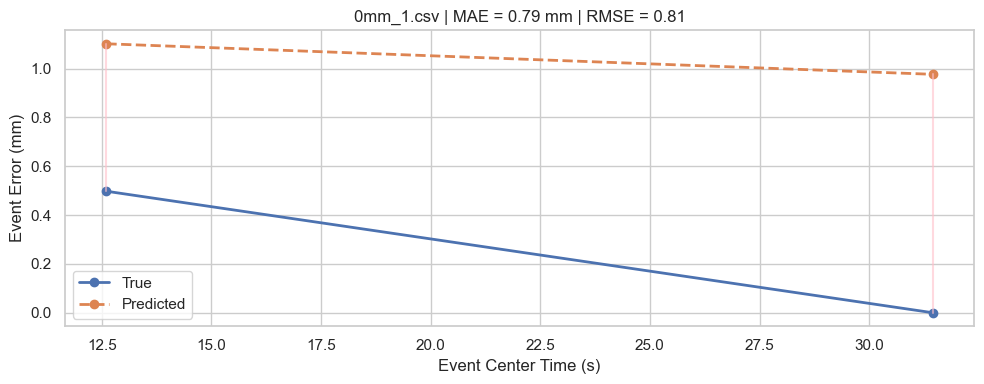

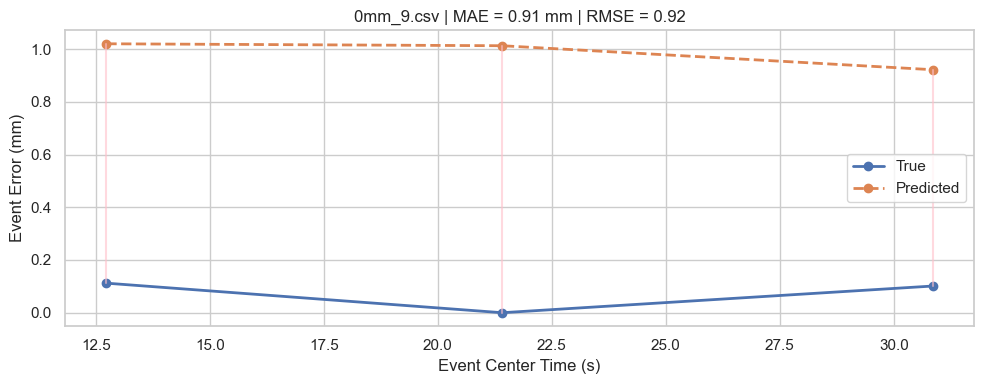

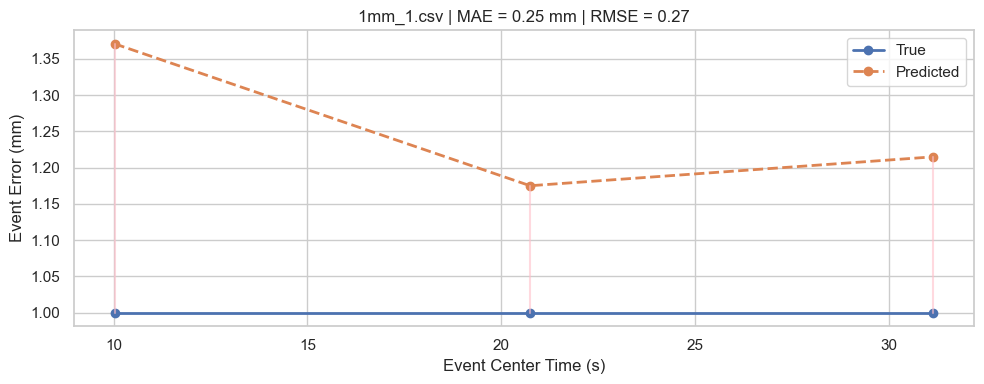

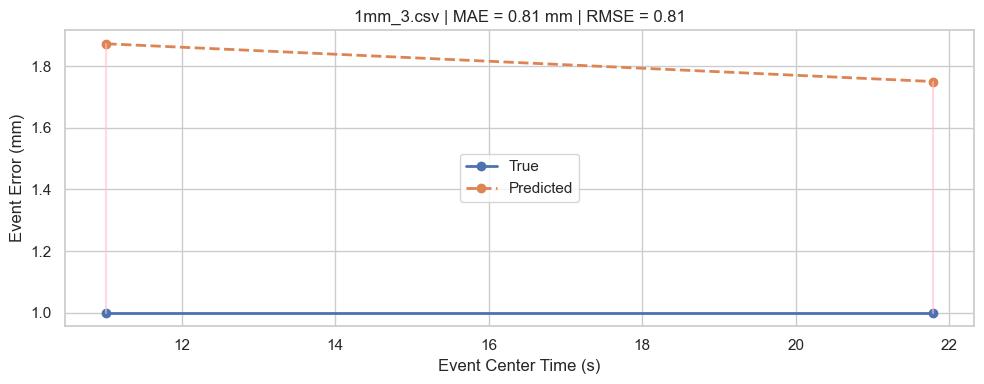

In [172]:
# True vs predicted over time for held-out trials
for trial_file, g in pred_df_static.groupby("Trial_File"):

    g = g.sort_values("event_center_time_sec").copy()
    g["residual"] = g["y_true"] - g["y_pred"]
    g["abs_error"] = np.abs(g["residual"])

    plt.figure(figsize=(10, 4))
    plt.plot(g["event_center_time_sec"], g["y_true"], marker="o", linewidth=2, label="True")
    plt.plot(g["event_center_time_sec"], g["y_pred"], marker="o", linewidth=2, linestyle="--", label="Predicted")

    for _, row in g.iterrows():
        plt.plot(
                    [row["event_center_time_sec"], row["event_center_time_sec"]],
                    [row["y_true"], row["y_pred"]],
                    linewidth=1.5,
                    alpha=0.6, 
                    color="pink"
                )

    plt.xlabel("Event Center Time (s)")
    plt.ylabel("Event Error (mm)")

    plt.title(
                    f"{trial_file} | MAE = {g['abs_error'].mean():.2f} mm | "
                    f"RMSE = {np.sqrt((g['residual']**2).mean()):.2f}"
             )
    
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 8. Stage 2 — Naive transfer to breathing conditions

The next question is whether a model trained only on static data generalizes to dynamic conditions.

This is evaluated by training on all static events and testing on dynamic events using the same baseline feature set.

In [173]:
'''
NAIVE DYNAMIC MODEL 
'''

naive_dynamic_model = clone(primary_model)
naive_dynamic_model.fit(X_static_basic, y_static)
y_dynamic_pred_basic = naive_dynamic_model.predict(X_dynamic_basic)

print("STAGE 2: NAIVE TRANSFER TO DYNAMIC")
print("----------------------------------")
print("R2:", r2_score(y_dynamic, y_dynamic_pred_basic))
print("RMSE:", np.sqrt(mean_squared_error(y_dynamic, y_dynamic_pred_basic)))
print("MAE:", mean_absolute_error(y_dynamic, y_dynamic_pred_basic))

STAGE 2: NAIVE TRANSFER TO DYNAMIC
----------------------------------
R2: -59.989750314650685
RMSE: 6.58245172117543
MAE: 6.338316039834788


In [174]:
dynamic_eval_basic_df = pd.DataFrame({
                                        "Trial_File": df_dynamic["Trial_File"],
                                        "Nominal_Class": df_dynamic["Nominal_Class"],
                                        "y_true": y_dynamic,
                                        "y_pred": y_dynamic_pred_basic
                                    })
dynamic_eval_basic_df["abs_error"] = np.abs(dynamic_eval_basic_df["y_true"] - dynamic_eval_basic_df["y_pred"])

<Figure size 700x400 with 0 Axes>

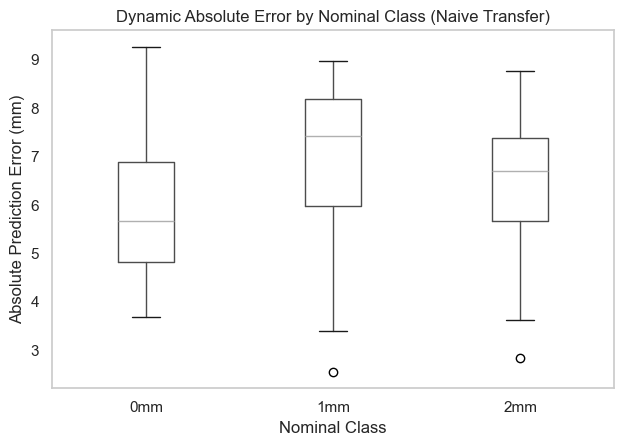

In [175]:
plt.figure(figsize=(7, 4))

dynamic_eval_basic_df.boxplot(column="abs_error", by="Nominal_Class", grid=False)

plt.suptitle("")
plt.title("Dynamic Absolute Error by Nominal Class (Naive Transfer)")
plt.xlabel("Nominal Class")
plt.ylabel("Absolute Prediction Error (mm)")
plt.tight_layout()
plt.show()

/var/folders/tv/8kr_xf_j7_12t3b_t5l75fs80000gn/T/ipykernel_33303/1092322491.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,Trial_File,Nominal_Class,n_events,MAE,RMSE
12,2mm_4.csv,2mm,3,5.268725,5.547102
10,2mm_2.csv,2mm,3,5.696517,5.898033
7,1mm_3.csv,1mm,3,5.836053,6.126599
3,0mm_4.csv,0mm,3,5.862784,5.932166
0,0mm_1.csv,0mm,3,5.897545,6.375723
1,0mm_2.csv,0mm,3,6.095395,6.110931
4,0mm_5.csv,0mm,3,6.120719,6.371280
11,2mm_3.csv,2mm,3,6.299357,6.460667
5,1mm_1.csv,1mm,3,6.445177,7.010632
2,0mm_3.csv,0mm,3,6.458984,6.636387


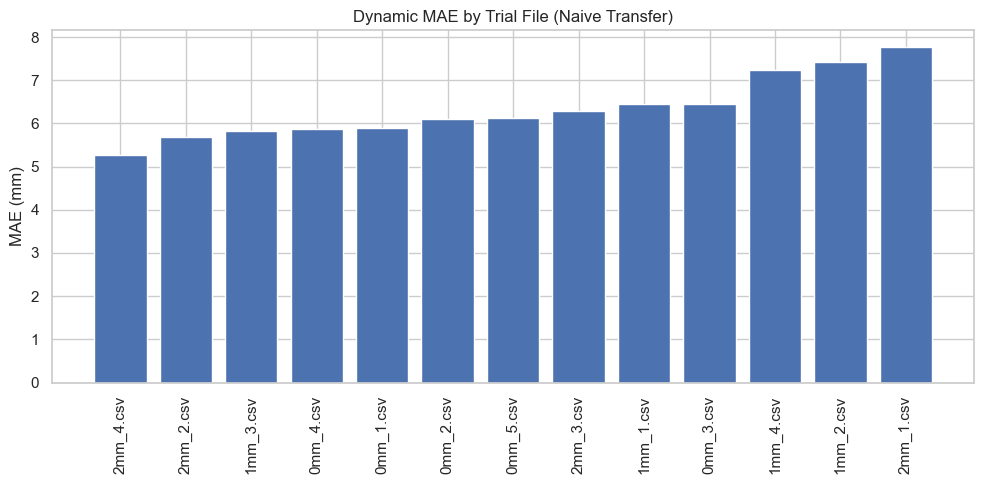

In [176]:
trial_dynamic_basic_summary = (
                                dynamic_eval_basic_df.groupby("Trial_File")
                                .apply(lambda g: pd.Series({
                                                                "Nominal_Class": g["Nominal_Class"].iloc[0],
                                                                "n_events": len(g),
                                                                "MAE": np.mean(np.abs(g["y_true"] - g["y_pred"])),
                                                                "RMSE": np.sqrt(np.mean((g["y_true"] - g["y_pred"])**2))
                                                            }))
                                .reset_index()
                                .sort_values("MAE")
                            )

display(trial_dynamic_basic_summary)

plt.figure(figsize=(10, 5))
plt.bar(trial_dynamic_basic_summary["Trial_File"], trial_dynamic_basic_summary["MAE"])
plt.xticks(rotation=90)
plt.ylabel("MAE (mm)")
plt.title("Dynamic MAE by Trial File (Naive Transfer)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

## 9. Why naive transfer fails: distribution shift

To interpret the dynamic failure, the static and dynamic feature distributions are compared.

If breathing changes the signal structure, then poor naive transfer is expected even if the static model itself is reasonable.

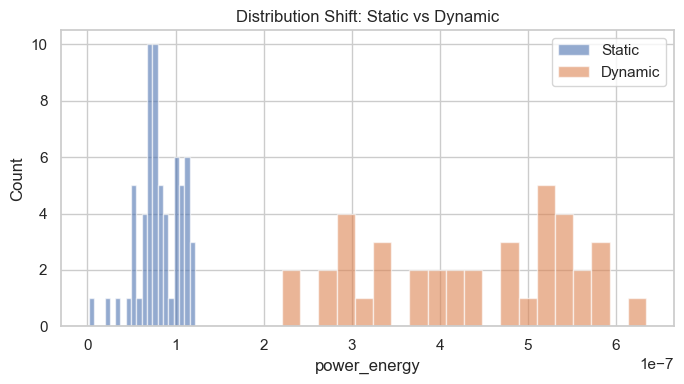

In [177]:
plt.figure(figsize=(7, 4))
plt.hist(df_static["power_energy"], bins=20, alpha=0.6, label="Static")
plt.hist(df_dynamic["power_energy"], bins=20, alpha=0.6, label="Dynamic")
plt.xlabel("power_energy")
plt.ylabel("Count")
plt.title("Distribution Shift: Static vs Dynamic")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

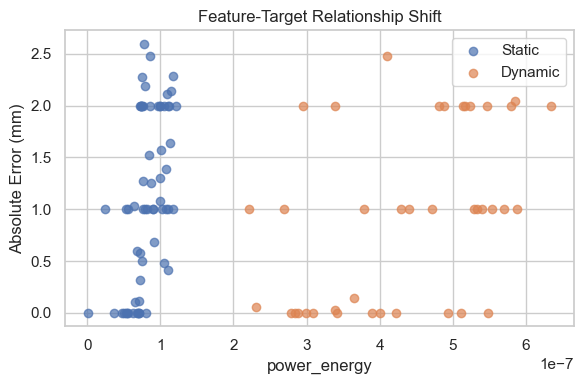

In [178]:
plt.figure(figsize=(6, 4))
plt.scatter(df_static["power_energy"], df_static[TARGET], label="Static", alpha=0.7)
plt.scatter(df_dynamic["power_energy"], df_dynamic[TARGET], label="Dynamic", alpha=0.7)
plt.xlabel("power_energy")
plt.ylabel("Absolute Error (mm)")
plt.legend()
plt.title("Feature-Target Relationship Shift")
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Stage 3 — Stable dynamic compensation

After showing that naive transfer fails, the main modeling question becomes whether breathing-aware features improve prediction under dynamic conditions.

Main comparison used in thesis:
1) Naive transfer: static-trained model on raw dynamic feature
2) Stable compensation: within-trial normalized dynamic feature

In [179]:
def metric_row(name, y_true, y_pred):
    return {
        "Model": name,
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }


In [180]:
model_naive = clone(primary_model)
model_naive.fit(X_static_basic, y_static)
y_pred_dynamic_naive = model_naive.predict(X_dynamic_basic)

In [181]:
def add_normalized_feature(df):
    df = df.copy()
    df["power_energy_norm"] = (
        df["power_energy"] /
        df.groupby("Trial_File")["power_energy"].transform("mean")
    )
    df["power_energy_centered"] = (
        df["power_energy"] -
        df.groupby("Trial_File")["power_energy"].transform("mean")
    )
    return df

In [182]:
df_static_norm = add_normalized_feature(df_static)
df_dynamic_norm = add_normalized_feature(df_dynamic)

X_static_norm = df_static_norm[["power_energy_norm"]].copy()
X_dynamic_norm = df_dynamic_norm[["power_energy_norm"]].copy()

model_comp = clone(primary_model)
model_comp.fit(X_static_norm, y_static)
y_pred_dynamic_comp = model_comp.predict(X_dynamic_norm)

In [183]:
results_dynamic_compare = pd.DataFrame([
    metric_row("Naive transfer (raw power_energy)", y_dynamic, y_pred_dynamic_naive),
    metric_row("Compensated transfer (within-trial normalized)", y_dynamic, y_pred_dynamic_comp),
])

print("DYNAMIC MODEL COMPARISON")
print("------------------------")
display(results_dynamic_compare)

DYNAMIC MODEL COMPARISON
------------------------


,Model,R2,RMSE,MAE
0,Naive transfer (raw power_energy),-59.989750,6.582452,6.338316
1,Compensated transfer (within-trial normalized),-0.054809,0.865658,0.748616


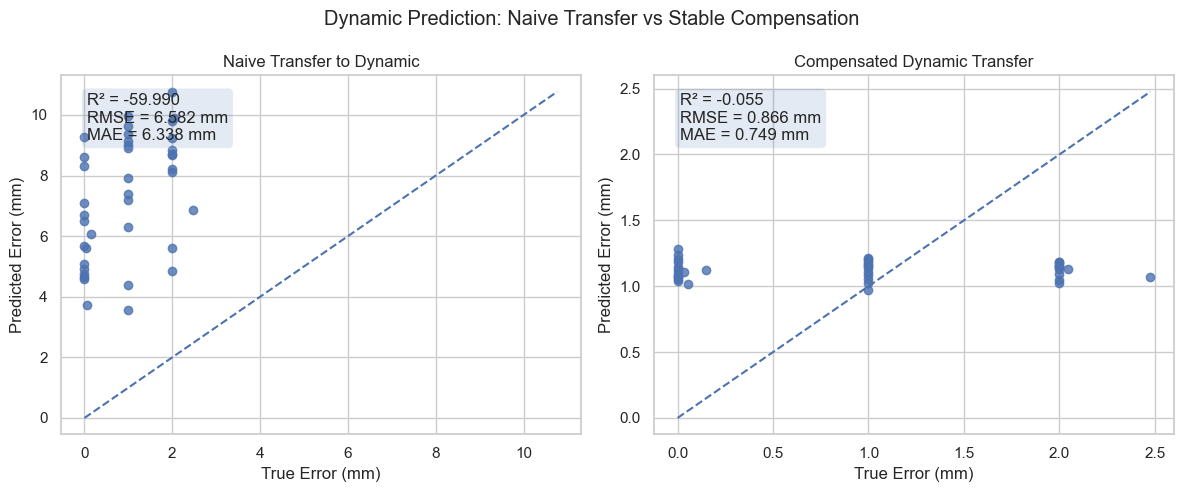

In [184]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Naive transfer
axes[0].scatter(y_dynamic, y_pred_dynamic_naive, alpha=0.8)
lims0 = [
    min(y_dynamic.min(), y_pred_dynamic_naive.min()),
    max(y_dynamic.max(), y_pred_dynamic_naive.max())
]
axes[0].plot(lims0, lims0, "--")
axes[0].set_title("Naive Transfer to Dynamic")
axes[0].set_xlabel("True Error (mm)")
axes[0].set_ylabel("Predicted Error (mm)")
axes[0].grid(True)

txt0 = (
    f"R² = {r2_score(y_dynamic, y_pred_dynamic_naive):.3f}\n"
    f"RMSE = {np.sqrt(mean_squared_error(y_dynamic, y_pred_dynamic_naive)):.3f} mm\n"
    f"MAE = {mean_absolute_error(y_dynamic, y_pred_dynamic_naive):.3f} mm"
)
axes[0].text(
    0.05, 0.95, txt0,
    transform=axes[0].transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

# Compensated transfer
axes[1].scatter(y_dynamic, y_pred_dynamic_comp, alpha=0.8)
lims1 = [
    min(y_dynamic.min(), y_pred_dynamic_comp.min()),
    max(y_dynamic.max(), y_pred_dynamic_comp.max())
]
axes[1].plot(lims1, lims1, "--")
axes[1].set_title("Compensated Dynamic Transfer")
axes[1].set_xlabel("True Error (mm)")
axes[1].set_ylabel("Predicted Error (mm)")
axes[1].grid(True)

txt1 = (
    f"R² = {r2_score(y_dynamic, y_pred_dynamic_comp):.3f}\n"
    f"RMSE = {np.sqrt(mean_squared_error(y_dynamic, y_pred_dynamic_comp)):.3f} mm\n"
    f"MAE = {mean_absolute_error(y_dynamic, y_pred_dynamic_comp):.3f} mm"
)
axes[1].text(
    0.05, 0.95, txt1,
    transform=axes[1].transAxes,
    va="top",
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.suptitle("Dynamic Prediction: Naive Transfer vs Stable Compensation")
plt.tight_layout()
plt.show()

In [185]:
# In-sample
model_insample = clone(primary_model)
model_insample.fit(X_static_basic, y_static)
y_pred_insample = model_insample.predict(X_static_basic)

metrics_compare = pd.DataFrame([
    {
        "Evaluation": "In-sample",
        "R2": r2_score(y_static, y_pred_insample),
        "MAE": mean_absolute_error(y_static, y_pred_insample),
        "RMSE": np.sqrt(mean_squared_error(y_static, y_pred_insample))
    },
    {
        "Evaluation": "Held-out",
        "R2": r2_score(y_test_static, y_test_pred_static),
        "MAE": mean_absolute_error(y_test_static, y_test_pred_static),
        "RMSE": np.sqrt(mean_squared_error(y_test_static, y_test_pred_static))
    },
    {
        "Evaluation": "Grouped CV",
        "R2": r2_score(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"]),
        "MAE": mean_absolute_error(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"]),
        "RMSE": np.sqrt(mean_squared_error(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"]))
    }
])

display(metrics_compare)

,Evaluation,R2,MAE,RMSE
0,In-sample,0.263324,0.604359,0.701445
1,Held-out,0.055711,0.522721,0.599168
2,Grouped CV,0.218774,0.623252,0.722343


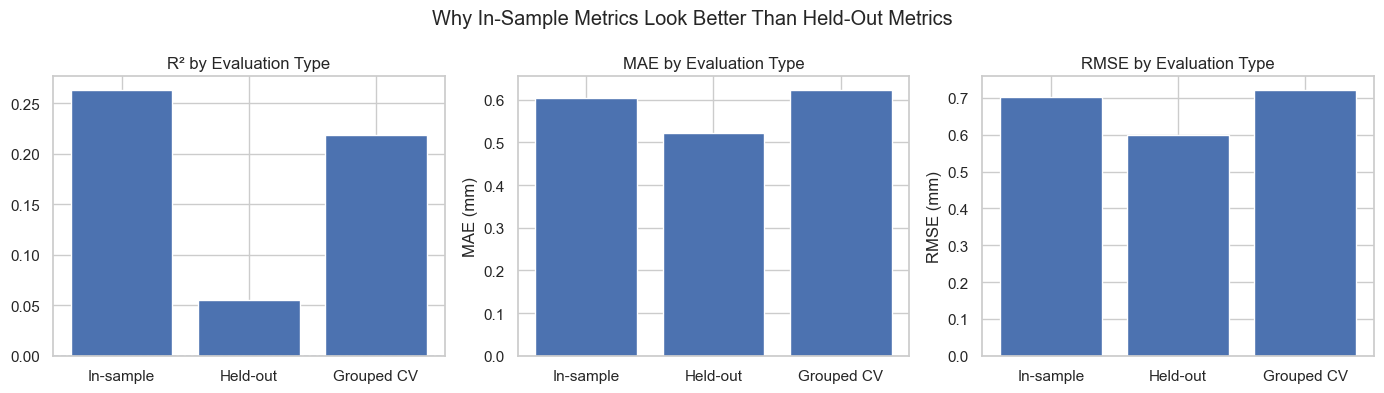

In [186]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(metrics_compare["Evaluation"], metrics_compare["R2"])
axes[0].set_title("R² by Evaluation Type")
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].grid(True, axis="y")

axes[1].bar(metrics_compare["Evaluation"], metrics_compare["MAE"])
axes[1].set_title("MAE by Evaluation Type")
axes[1].set_ylabel("MAE (mm)")
axes[1].grid(True, axis="y")

axes[2].bar(metrics_compare["Evaluation"], metrics_compare["RMSE"])
axes[2].set_title("RMSE by Evaluation Type")
axes[2].set_ylabel("RMSE (mm)")
axes[2].grid(True, axis="y")

plt.suptitle("Why In-Sample Metrics Look Better Than Held-Out Metrics")
plt.tight_layout()
plt.show()

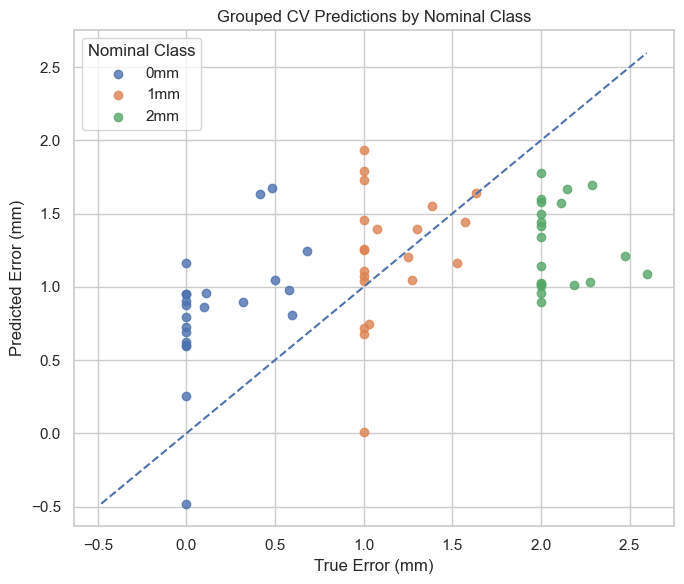

In [187]:
plt.figure(figsize=(7, 6))

for cls in sorted(cv_pred_static_df["Nominal_Class"].unique()):
    g = cv_pred_static_df[cv_pred_static_df["Nominal_Class"] == cls]
    plt.scatter(g["y_true"], g["y_pred"], alpha=0.8, label=cls)

lims = [
    min(cv_pred_static_df["y_true"].min(), cv_pred_static_df["y_pred"].min()),
    max(cv_pred_static_df["y_true"].max(), cv_pred_static_df["y_pred"].max())
]
plt.plot(lims, lims, "--")
plt.xlabel("True Error (mm)")
plt.ylabel("Predicted Error (mm)")
plt.title("Grouped CV Predictions by Nominal Class")
plt.legend(title="Nominal Class")
plt.grid(True)
plt.tight_layout()
plt.show()

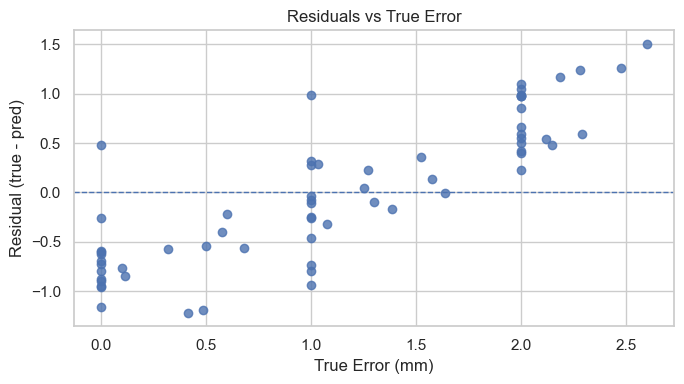

In [188]:
cv_pred_static_df["residual"] = cv_pred_static_df["y_true"] - cv_pred_static_df["y_pred"]

plt.figure(figsize=(7, 4))
plt.scatter(cv_pred_static_df["y_true"], cv_pred_static_df["residual"], alpha=0.8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("True Error (mm)")
plt.ylabel("Residual (true - pred)")
plt.title("Residuals vs True Error")
plt.grid(True)
plt.tight_layout()
plt.show()

,true_bin,n,mean_abs_error,median_abs_error
0,"(-0.0026, 0.649]",21,0.731513,0.726715
1,"(0.649, 1.298]",18,0.376345,0.283790
2,"(1.298, 1.947]",4,0.164799,0.148135
3,"(1.947, 2.596]",21,0.813949,0.860883


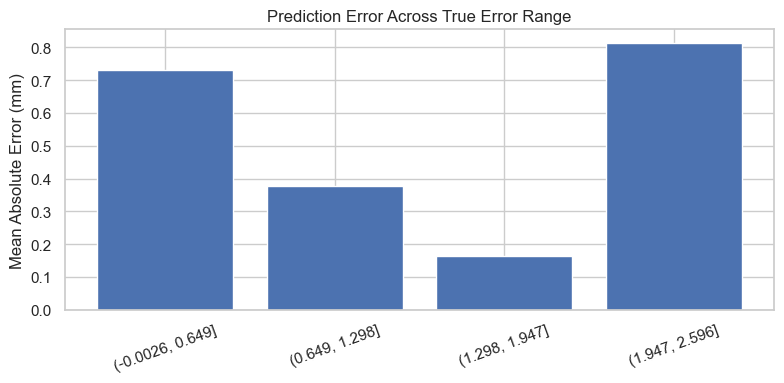

In [189]:
tmp = cv_pred_static_df.copy()
tmp["true_bin"] = pd.cut(tmp["y_true"], bins=4)

bin_summary = (
    tmp.groupby("true_bin", observed=False)
    .agg(
        n=("abs_error", "count"),
        mean_abs_error=("abs_error", "mean"),
        median_abs_error=("abs_error", "median")
    )
    .reset_index()
)

display(bin_summary)

plt.figure(figsize=(8, 4))
plt.bar(bin_summary["true_bin"].astype(str), bin_summary["mean_abs_error"])
plt.xticks(rotation=20)
plt.ylabel("Mean Absolute Error (mm)")
plt.title("Prediction Error Across True Error Range")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

,Nominal_Class,mean_true,mean_pred,std_true,std_pred
0,0mm,0.171901,0.851927,0.246857,0.435598
1,1mm,1.144732,1.220180,0.217220,0.440412
2,2mm,2.099115,1.285166,0.173557,0.287572


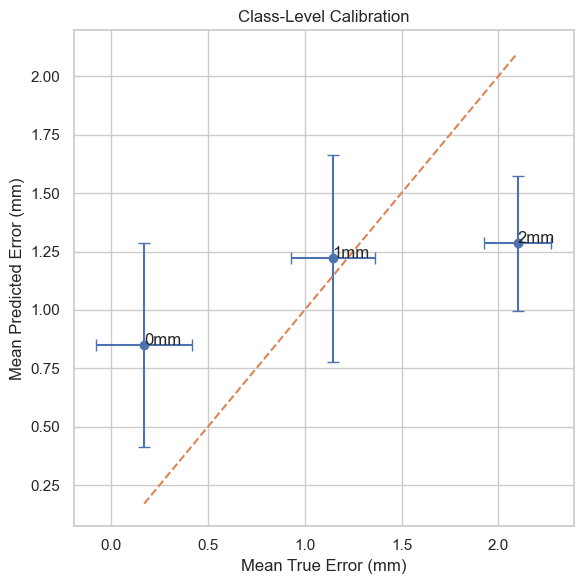

In [190]:
class_cal = (
    cv_pred_static_df.groupby("Nominal_Class")
    .agg(
        mean_true=("y_true", "mean"),
        mean_pred=("y_pred", "mean"),
        std_true=("y_true", "std"),
        std_pred=("y_pred", "std")
    )
    .reset_index()
)

display(class_cal)

plt.figure(figsize=(6, 6))
plt.errorbar(
    class_cal["mean_true"],
    class_cal["mean_pred"],
    xerr=class_cal["std_true"],
    yerr=class_cal["std_pred"],
    fmt="o",
    capsize=4
)

lims = [
    min(class_cal["mean_true"].min(), class_cal["mean_pred"].min()),
    max(class_cal["mean_true"].max(), class_cal["mean_pred"].max())
]
plt.plot(lims, lims, "--")
for _, row in class_cal.iterrows():
    plt.text(row["mean_true"], row["mean_pred"], row["Nominal_Class"])

plt.xlabel("Mean True Error (mm)")
plt.ylabel("Mean Predicted Error (mm)")
plt.title("Class-Level Calibration")
plt.grid(True)
plt.tight_layout()
plt.show()

## 13. Final reporting summary

This final table collects the main values used in thesis writing and defense slides.

In [191]:
summary_df = pd.DataFrame([{

    "Static_events": len(df_static),
    "Static_trial_files": groups_static.nunique(),
    "Dynamic_events": len(df_dynamic),
    "Dynamic_trial_files": groups_dynamic.nunique(),

    "Static_Grouped_CV_R2_mean": cv_r2_static.mean(),
    "Static_Grouped_CV_R2_std": cv_r2_static.std(),
    "Static_Grouped_CV_RMSE_mean": cv_rmse_static.mean(),
    "Static_Grouped_CV_MAE_mean": cv_mae_static.mean(),

    "Repeated_holdout_median_R2": repeated_results_df["R2"].median(),
    "Repeated_holdout_median_RMSE": repeated_results_df["RMSE"].median(),
    "Repeated_holdout_median_MAE": repeated_results_df["MAE"].median(),
    "Repeated_holdout_pct_R2_gt_0": (repeated_results_df["R2"] > 0).mean() * 100,

    "Dynamic_Naive_R2": r2_score(y_dynamic, y_pred_dynamic_naive),
    "Dynamic_Naive_RMSE": np.sqrt(mean_squared_error(y_dynamic, y_pred_dynamic_naive)),
    "Dynamic_Naive_MAE": mean_absolute_error(y_dynamic, y_pred_dynamic_naive),

    "Dynamic_Comp_R2": r2_score(y_dynamic, y_pred_dynamic_comp),
    "Dynamic_Comp_RMSE": np.sqrt(mean_squared_error(y_dynamic, y_pred_dynamic_comp)),
    "Dynamic_Comp_MAE": mean_absolute_error(y_dynamic, y_pred_dynamic_comp),

}])

print("FINAL REPORTING SUMMARY")
print("-----------------------")
display(summary_df)

FINAL REPORTING SUMMARY
-----------------------


,Static_events,Static_trial_files,Dynamic_events,Dynamic_trial_files,Static_Grouped_CV_R2_mean,Static_Grouped_CV_R2_std,Static_Grouped_CV_RMSE_mean,Static_Grouped_CV_MAE_mean,Repeated_holdout_median_R2,Repeated_holdout_median_RMSE,Repeated_holdout_median_MAE,Repeated_holdout_pct_R2_gt_0,Dynamic_Naive_R2,Dynamic_Naive_RMSE,Dynamic_Naive_MAE,Dynamic_Comp_R2,Dynamic_Comp_RMSE,Dynamic_Comp_MAE
0,64,25,39,13,0.243938,0.279403,0.679762,0.627151,0.106968,0.747701,0.64478,65.0,-59.98975,6.582452,6.338316,-0.054809,0.865658,0.748616


## 12. Final synthesis figure

The following figure summarizes the full modeling progression:

- **A:** static mapping works  
- **B:** naive dynamic transfer fails  
- **C:** static and dynamic distributions differ  
- **D:** compensation partially recovers performance

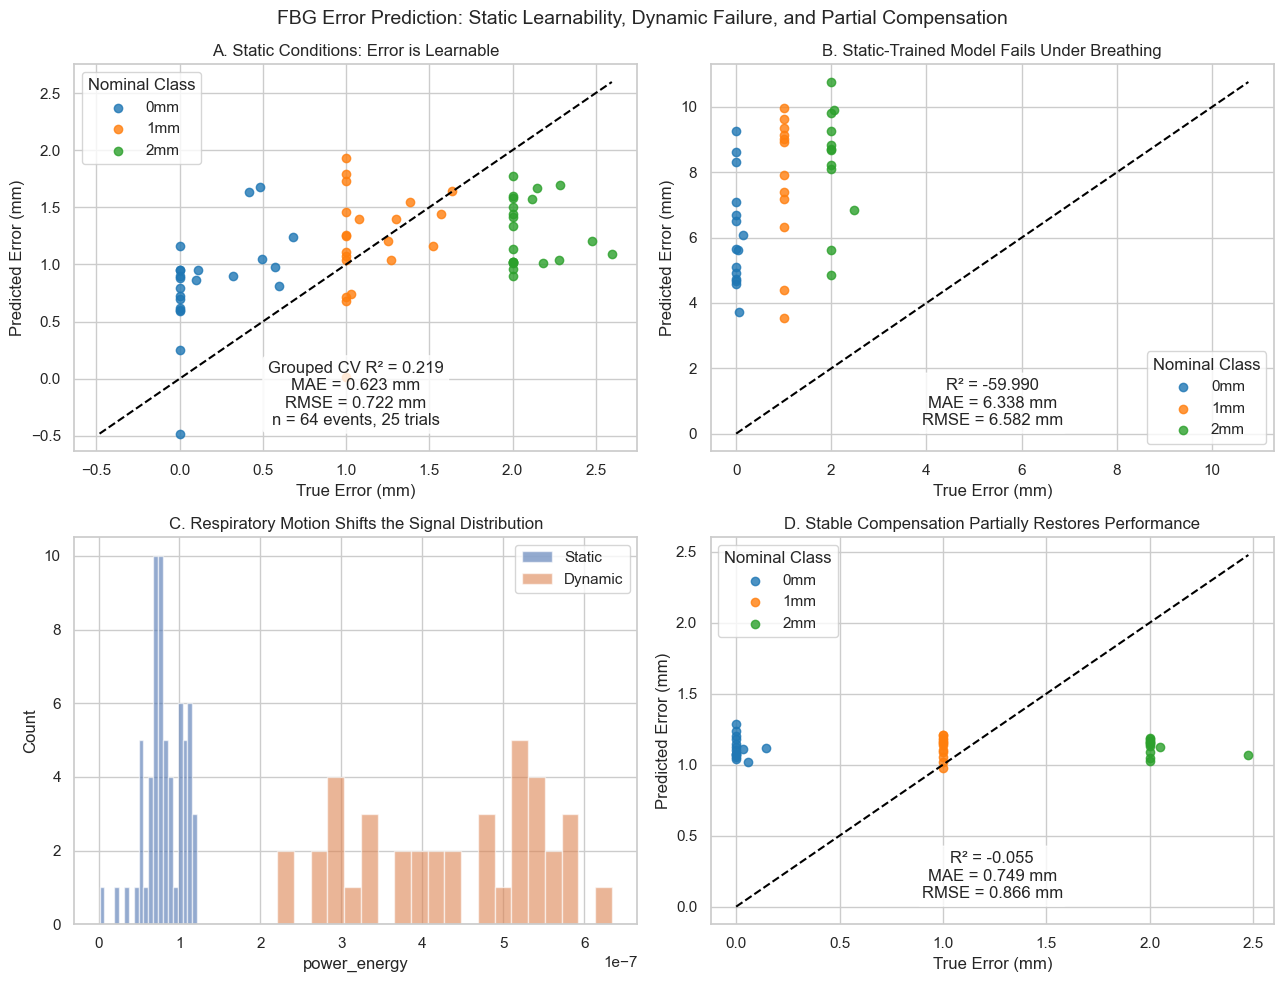

In [192]:
# Grouped CV metrics for panel A
static_cv_r2 = r2_score(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"])
static_cv_mae = mean_absolute_error(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"])
static_cv_rmse = np.sqrt(mean_squared_error(cv_pred_static_df["y_true"], cv_pred_static_df["y_pred"]))

# Dynamic metrics
naive_r2 = r2_score(y_dynamic, y_pred_dynamic_naive)
naive_mae = mean_absolute_error(y_dynamic, y_pred_dynamic_naive)
naive_rmse = np.sqrt(mean_squared_error(y_dynamic, y_pred_dynamic_naive))

comp_r2 = r2_score(y_dynamic, y_pred_dynamic_comp)
comp_mae = mean_absolute_error(y_dynamic, y_pred_dynamic_comp)
comp_rmse = np.sqrt(mean_squared_error(y_dynamic, y_pred_dynamic_comp))

# ---------------------------------------------------------
# Build dynamic plotting dataframes so nominal class colors
# can be used consistently in Panels B and D
# ---------------------------------------------------------
dynamic_naive_df = pd.DataFrame({
    "Nominal_Class": df_dynamic["Nominal_Class"].values,
    "y_true": y_dynamic.values if hasattr(y_dynamic, "values") else y_dynamic,
    "y_pred": y_pred_dynamic_naive
})

dynamic_comp_df = pd.DataFrame({
    "Nominal_Class": df_dynamic["Nominal_Class"].values,
    "y_true": y_dynamic.values if hasattr(y_dynamic, "values") else y_dynamic,
    "y_pred": y_pred_dynamic_comp
})

# Consistent class color mapping
class_order = sorted(df_static["Nominal_Class"].unique())
class_colors = {
    "0mm": "tab:blue",
    "1mm": "tab:orange",
    "2mm": "tab:green"
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# ---------------------------------------------------------
# Panel A — Static learnability
# ---------------------------------------------------------
ax = axes[0, 0]
for cls in class_order:
    g = cv_pred_static_df[cv_pred_static_df["Nominal_Class"] == cls]
    ax.scatter(
        g["y_true"], g["y_pred"],
        alpha=0.8,
        label=cls,
        color=class_colors.get(cls, None)
    )

limsA = [
    min(cv_pred_static_df["y_true"].min(), cv_pred_static_df["y_pred"].min()),
    max(cv_pred_static_df["y_true"].max(), cv_pred_static_df["y_pred"].max())
]
ax.plot(limsA, limsA, "--", color="black")
ax.set_title("A. Static Conditions: Error is Learnable")
ax.set_xlabel("True Error (mm)")
ax.set_ylabel("Predicted Error (mm)")
ax.grid(True)
ax.legend(title="Nominal Class")

txtA = (
    f"Grouped CV R² = {static_cv_r2:.3f}\n"
    f"MAE = {static_cv_mae:.3f} mm\n"
    f"RMSE = {static_cv_rmse:.3f} mm\n"
    f"n = {len(df_static)} events, {groups_static.nunique()} trials"
)
ax.text(
    0.50, 0.06, txtA,
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# ---------------------------------------------------------
# Panel B — Naive transfer failure
# ---------------------------------------------------------
ax = axes[0, 1]
for cls in class_order:
    g = dynamic_naive_df[dynamic_naive_df["Nominal_Class"] == cls]
    ax.scatter(
        g["y_true"], g["y_pred"],
        alpha=0.8,
        label=cls,
        color=class_colors.get(cls, None)
    )

limsB = [
    min(dynamic_naive_df["y_true"].min(), dynamic_naive_df["y_pred"].min()),
    max(dynamic_naive_df["y_true"].max(), dynamic_naive_df["y_pred"].max())
]
ax.plot(limsB, limsB, "--", color="black")
ax.set_title("B. Static-Trained Model Fails Under Breathing")
ax.set_xlabel("True Error (mm)")
ax.set_ylabel("Predicted Error (mm)")
ax.grid(True)
ax.legend(title="Nominal Class")

txtB = (
    f"R² = {naive_r2:.3f}\n"
    f"MAE = {naive_mae:.3f} mm\n"
    f"RMSE = {naive_rmse:.3f} mm"
)
ax.text(
    0.50, 0.06, txtB,
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# ---------------------------------------------------------
# Panel C — Distribution shift
# ---------------------------------------------------------
ax = axes[1, 0]
ax.hist(df_static["power_energy"], bins=20, alpha=0.6, label="Static")
ax.hist(df_dynamic["power_energy"], bins=20, alpha=0.6, label="Dynamic")
ax.set_title("C. Respiratory Motion Shifts the Signal Distribution")
ax.set_xlabel("power_energy")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True)

# ---------------------------------------------------------
# Panel D — Partial recovery
# ---------------------------------------------------------
ax = axes[1, 1]
for cls in class_order:
    g = dynamic_comp_df[dynamic_comp_df["Nominal_Class"] == cls]
    ax.scatter(
        g["y_true"], g["y_pred"],
        alpha=0.8,
        label=cls,
        color=class_colors.get(cls, None)
    )

limsD = [
    min(dynamic_comp_df["y_true"].min(), dynamic_comp_df["y_pred"].min()),
    max(dynamic_comp_df["y_true"].max(), dynamic_comp_df["y_pred"].max())
]
ax.plot(limsD, limsD, "--", color="black")
ax.set_title("D. Stable Compensation Partially Restores Performance")
ax.set_xlabel("True Error (mm)")
ax.set_ylabel("Predicted Error (mm)")
ax.grid(True)
ax.legend(title="Nominal Class")

txtD = (
    f"R² = {comp_r2:.3f}\n"
    f"MAE = {comp_mae:.3f} mm\n"
    f"RMSE = {comp_rmse:.3f} mm"
)
ax.text(
    0.50, 0.06, txtD,
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.suptitle(
    "FBG Error Prediction: Static Learnability, Dynamic Failure, and Partial Compensation",
    fontsize=14
)
plt.tight_layout()
plt.show()